# Kiểm thử mô hình nhận diện khuôn mặt trong Humanity OS


## Section 1: So sánh mô hình

In [22]:
# Block 5.1: Thiết lập cấu hình và tham số
import os
import random
import time
import gc
import numpy as np
import pandas as pd
from pathlib import Path
import face_recognition
from deepface import DeepFace
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

USERS_NEW = [
    'Andy Samberg', 'Anushka Sharma', 'Billie Eilish', 'Camila Cabello', 'Courtney Cox',
    'Dwayne Johnson', 'Ellen Degeneres', 'Hrithik Roshan', 'Roger Federer', 'Tom Cruise'
]
DATASET_DIR_NEW = '../dataset'
REFERENCE_DIR_NEW = '../reference_images'
OUTPUT_DIR_NEW = 'results_new'
TOLERANCE_NEW = 0.6
IMAGE_SIZE_NEW = (320, 240) 
JPEG_QUALITY_NEW = 70
NUM_REFERENCES_NEW = 1
NUM_TEST_IMAGES_NEW = 10
DEEPFACE_MODEL_NEW = 'SFace'
DEEPFACE_DISTANCE_NEW = 'cosine'
DEEPFACE_THRESHOLD_NEW = 0.3

os.makedirs(OUTPUT_DIR_NEW, exist_ok=True)
random.seed(42)

# Tạo thư mục cache DeepFace và cấp quyền
home = os.path.expanduser("~")
deepface_cache = os.path.join(home, '.deepface/weights')
os.makedirs(deepface_cache, exist_ok=True)
os.chmod(home + '/.deepface', 0o755)
os.chmod(deepface_cache, 0o755)

# Clear DeepFace cache
if os.path.exists(deepface_cache):
    import shutil
    shutil.rmtree(deepface_cache)
    os.makedirs(deepface_cache)
    print(f'Đã xóa và tạo lại cache DeepFace tại {deepface_cache}')

# Preload DeepFace model
print(f'Tải trước model {DEEPFACE_MODEL_NEW}...')
try:
    DeepFace.verify(img1_path=os.path.join(REFERENCE_DIR_NEW, f'{USERS_NEW[0]}_0.jpg'),
                    img2_path=os.path.join(REFERENCE_DIR_NEW, f'{USERS_NEW[0]}_0.jpg'),
                    model_name=DEEPFACE_MODEL_NEW, distance_metric=DEEPFACE_DISTANCE_NEW,
                    enforce_detection=False)
    print(f'Model {DEEPFACE_MODEL_NEW} đã tải.')
except Exception as e:
    print(f'Lỗi khi tải model {DEEPFACE_MODEL_NEW}: {e}. Thử cài lại DeepFace: pip install --force-reinstall deepface')
    exit(1)
print('Setup so sánh mô hình mới hoàn tất.')


Đã xóa và tạo lại cache DeepFace tại /home/lochuynh/.deepface/weights
Tải trước model SFace...
Model SFace đã tải.
Setup so sánh mô hình mới hoàn tất.


In [23]:
# Block 2: Hàm xử lý ảnh và kiểm tra khuôn mặt
def process_image_new(img_path, size=IMAGE_SIZE_NEW, quality=JPEG_QUALITY_NEW):
    try:
        img = face_recognition.load_image_file(img_path)
        img = np.array(img)
        if img.shape[0] > size[1] or img.shape[1] > size[0]:
            from PIL import Image
            img_pil = Image.fromarray(img)
            img_pil = img_pil.resize(size, Image.LANCZOS)
            img = np.array(img_pil)
        return img
    except Exception as e:
        print(f'Lỗi khi xử lý ảnh {img_path}: {e}')
        return None

def verify_face_fr_new(img, reference_encodings, tolerance):
    encodings = face_recognition.face_encodings(img)
    if not encodings:
        return None, 'No Face Detected in Test'
    encoding = encodings[0]
    for ref_user, ref_encs in reference_encodings.items():
        for ref_enc in ref_encs:
            distance = face_recognition.face_distance([ref_enc], encoding)[0]
            if distance <= tolerance:
                return ref_user, 'Match'
    return None, 'No Match'

def verify_face_deepface_new(img_path, reference_paths, model_name, distance_metric, threshold):
    img = process_image_new(img_path)  
    if img is None:
        return None, 'No Face Detected in Test'
    try:
        from PIL import Image
        import tempfile
        with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp_file:
            Image.fromarray(img).save(tmp_file.name, quality=JPEG_QUALITY_NEW)
            for ref_user, ref_path in reference_paths.items():
                try:
                    result = DeepFace.verify(img1_path=ref_path, img2_path=tmp_file.name,
                                             model_name=model_name, distance_metric=distance_metric,
                                             enforce_detection=False)
                    if result['verified']:
                        return ref_user, 'Match'
                except Exception as e:
                    print(f'Lỗi DeepFace với {img_path} vs {ref_path}: {e}')
                    continue
        os.unlink(tmp_file.name)
    except Exception as e:
        print(f'Lỗi xử lý DeepFace cho {img_path}: {e}')
    return None, 'No Match'

def load_reference_images_new(num_refs):
    reference_encodings_fr = {}
    reference_paths_df = {}
    invalid_users = []
    for user in USERS_NEW:
        ref_path = os.path.join(REFERENCE_DIR_NEW, f'{user}_0.jpg')
        if not os.path.exists(ref_path):
            print(f'Không tìm thấy ảnh tham chiếu cho {user}: {ref_path}')
            invalid_users.append(user)
            continue
        img = process_image_new(ref_path)
        if img is None:
            print(f'Lỗi xử lý ảnh tham chiếu {ref_path}')
            invalid_users.append(user)
            continue
        encodings = face_recognition.face_encodings(img)
        if not encodings:
            print(f'Không phát hiện khuôn mặt trong ảnh tham chiếu {ref_path}')
            invalid_users.append(user)
            continue
        reference_encodings_fr[user] = encodings
        reference_paths_df[user] = ref_path
    if not reference_encodings_fr:
        print('Không có user hợp lệ. Kiểm tra lại ảnh tham chiếu.')
        exit(1)
    return reference_encodings_fr, reference_paths_df, invalid_users

def calculate_comparison_metrics_new(df):
    metrics = {
        'Model': ['face_recognition', 'DeepFace'],
        'Accuracy': [0.0, 0.0],
        'Mean_Time': [0.0, 0.0],
        'Num_Users': [0, 0]
    }
    
    valid_df = df[df['Status_FR'] != 'No Face Detected in Reference']
    valid_df = valid_df[valid_df['Status_DF'] != 'No Face Detected in Reference']
    
    if valid_df.empty:
        print('Không có dữ liệu hợp lệ để tính metrics.')
        return pd.DataFrame(metrics)
    
    num_users = valid_df['True_User'].nunique()
    
    for model, status_col, pred_col in [('face_recognition', 'Status_FR', 'Predicted_User_FR'), 
                                        ('DeepFace', 'Status_DF', 'Predicted_User_DF')]:
        correct = 0
        total = 0
        for user in valid_df['True_User'].unique():
            user_df = valid_df[valid_df['True_User'] == user]
            for target in user_df['Target_Folder'].unique():
                target_df = user_df[user_df['Target_Folder'] == target]
                final_status = target_df.iloc[-1][status_col] if not target_df.empty else 'No Match'
                if user == target:
                    if final_status == 'Correct Match':
                        correct += 1
                else:
                    if final_status in ['No Match', 'Incorrect Match']:
                        correct += 1
                total += 1
        metrics['Accuracy'][['face_recognition', 'DeepFace'].index(model)] = correct / total if total > 0 else 0.0
    
    metrics['Mean_Time'] = [
        valid_df['Time_FR'].mean() if not valid_df.empty else 0.0,
        valid_df['Time_DF'].mean() if not valid_df.empty else 0.0
    ]
    metrics['Num_Users'] = [num_users, num_users]
    
    return pd.DataFrame(metrics)

def run_comparison_test_new():
    reference_encodings_fr, reference_paths_df, invalid_users = load_reference_images_new(NUM_REFERENCES_NEW)
    results = []
    for true_user in USERS_NEW:
        if true_user in invalid_users:
            for target_folder in USERS_NEW:
                results.append({
                    'True_User': true_user,
                    'Target_Folder': target_folder,
                    'Predicted_User_FR': None,
                    'Status_FR': 'No Face Detected in Reference',
                    'Time_FR': 0.0,
                    'Predicted_User_DF': None,
                    'Status_DF': 'No Face Detected in Reference',
                    'Time_DF': 0.0,
                    'Test_Image_Path': None
                })
            continue

        ref_path = os.path.join(REFERENCE_DIR_NEW, f'{true_user}_0.jpg')
        for target_folder in USERS_NEW:
            target_dir = Path(DATASET_DIR_NEW) / target_folder
            if not target_dir.exists():
                print(f'Không tìm thấy thư mục kiểm thử cho {target_folder}')
                results.append({
                    'True_User': true_user,
                    'Target_Folder': target_folder,
                    'Predicted_User_FR': None,
                    'Status_FR': 'No Test Images',
                    'Time_FR': 0.0,
                    'Predicted_User_DF': None,
                    'Status_DF': 'No Test Images',
                    'Time_DF': 0.0,
                    'Test_Image_Path': None
                })
                continue

            test_images = list(target_dir.glob('*.jpg'))
            if len(test_images) < NUM_TEST_IMAGES_NEW:
                print(f'Không đủ ảnh kiểm thử cho {target_folder}: {len(test_images)} có sẵn, cần {NUM_TEST_IMAGES_NEW}')
            random.shuffle(test_images)
            test_images = test_images[:NUM_TEST_IMAGES_NEW]

            match_found = False
            for img_path in test_images:
                img = process_image_new(img_path)
                if img is None:
                    continue

                # face_recognition
                start_time_fr = time.time()
                predicted_user_fr, status_fr = verify_face_fr_new(img, reference_encodings_fr, TOLERANCE_NEW)
                time_fr = time.time() - start_time_fr

                # DeepFace
                start_time_df = time.time()
                predicted_user_df, status_df = verify_face_deepface_new(str(img_path), reference_paths_df, 
                                                                       DEEPFACE_MODEL_NEW, DEEPFACE_DISTANCE_NEW, 
                                                                       DEEPFACE_THRESHOLD_NEW)
                time_df = time.time() - start_time_df

                # Determine status based on new logic
                status_fr_final = status_fr
                status_df_final = status_df
                if status_fr == 'Match':
                    status_fr_final = 'Correct Match' if predicted_user_fr == true_user and target_folder == true_user else 'Incorrect Match'
                if status_df == 'Match':
                    status_df_final = 'Correct Match' if predicted_user_df == true_user and target_folder == true_user else 'Incorrect Match'

                results.append({
                    'True_User': true_user,
                    'Target_Folder': target_folder,
                    'Predicted_User_FR': predicted_user_fr,
                    'Status_FR': status_fr_final,
                    'Time_FR': time_fr,
                    'Predicted_User_DF': predicted_user_df,
                    'Status_DF': status_df_final,
                    'Time_DF': time_df,
                    'Test_Image_Path': str(img_path)
                })

                if status_fr_final in ['Correct Match', 'Incorrect Match'] or status_df_final in ['Correct Match', 'Incorrect Match']:
                    print(f'True User: {true_user}, Target: {target_folder}, '
                          f'Status_FR: {status_fr_final}, Time_FR: {time_fr:.2f}s, '
                          f'Status_DF: {status_df_final}, Time_DF: {time_df:.2f}s')
                    match_found = True
                    break

            if not match_found:
                results.append({
                    'True_User': true_user,
                    'Target_Folder': target_folder,
                    'Predicted_User_FR': None,
                    'Status_FR': 'No Match',
                    'Time_FR': sum(r['Time_FR'] for r in results if r['True_User'] == true_user and r['Target_Folder'] == target_folder),
                    'Predicted_User_DF': None,
                    'Status_DF': 'No Match',
                    'Time_DF': sum(r['Time_DF'] for r in results if r['True_User'] == true_user and r['Target_Folder'] == target_folder),
                    'Test_Image_Path': None
                })

            # Giải phóng bộ nhớ sau mỗi folder
            gc.collect()
            tf.keras.backend.clear_session()

        # Save results after each user
        pd.DataFrame(results).to_csv(os.path.join(OUTPUT_DIR_NEW, 'comparison_results_new.csv'), index=False)

    return pd.DataFrame(results)


In [ ]:
# Block 3: Chạy kiểm thử so sánh

print('Kiểm tra ảnh tham chiếu...')
valid_users = []
for user in USERS_NEW:
    ref_path = os.path.join(REFERENCE_DIR_NEW, f'{user}_0.jpg')
    img = process_image_new(ref_path)
    if img is not None and len(face_recognition.face_encodings(img)) > 0:
        valid_users.append(user)
    else:
        print(f'Ảnh tham chiếu không hợp lệ: {ref_path}')
if len(valid_users) < len(USERS_NEW):
    print(f'Chỉ có {len(valid_users)} user hợp lệ: {valid_users}. Cập nhật USERS_NEW.')
    USERS_NEW = valid_users
if not valid_users:
    print('Không có user hợp lệ. Thoát chương trình.')
    exit(1)

# Run comparison and save results
results_df_new = run_comparison_test_new()
if not results_df_new.empty:
    results_df_new.to_csv(os.path.join(OUTPUT_DIR_NEW, 'comparison_results_new.csv'), index=False)
    print(f'Kết quả lưu tại {os.path.join(OUTPUT_DIR_NEW, "comparison_results_new.csv")}')

# Calculate metrics
metrics_new = calculate_comparison_metrics_new(results_df_new)
metrics_new.to_csv(os.path.join(OUTPUT_DIR_NEW, 'comparison_metrics_new.csv'), index=False)
print(f'Metrics so sánh lưu tại {os.path.join(OUTPUT_DIR_NEW, "comparison_metrics_new.csv")}')

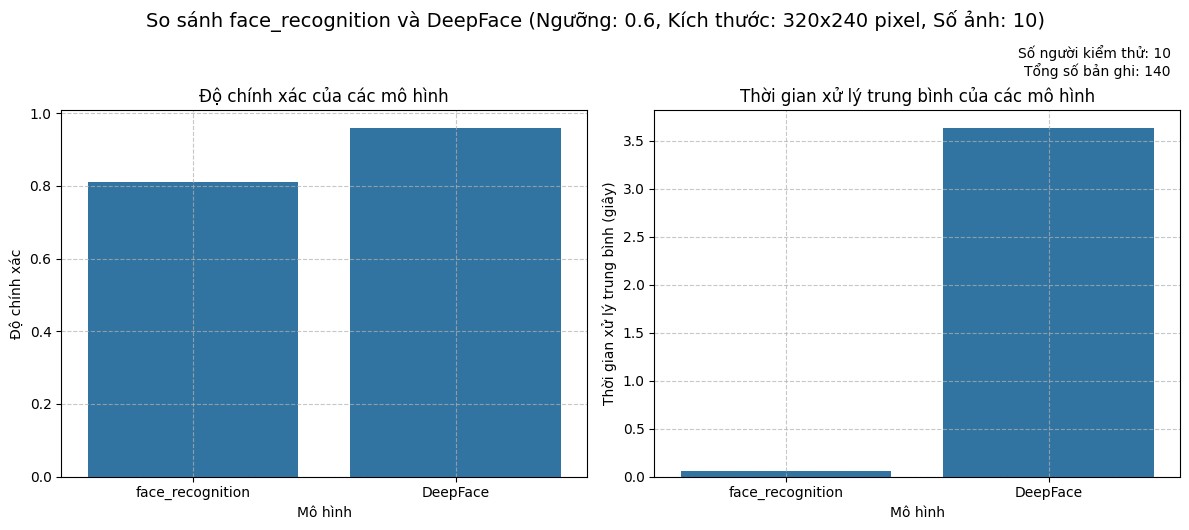

Biểu đồ so sánh mô hình lưu tại results_new/comparison_models_new.png


In [24]:
# Block 4: Vẽ biểu đồ

try:
    results_df_new
except NameError:
    results_df_new = pd.read_csv(os.path.join(OUTPUT_DIR_NEW, 'comparison_results_new.csv'))

try:
    metrics_new
except NameError:
    metrics_new = pd.read_csv(os.path.join(OUTPUT_DIR_NEW, 'comparison_metrics_new.csv'))

if results_df_new.empty or metrics_new.empty:
    print('Không có dữ liệu để vẽ biểu đồ.')
    exit(1)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
sns.barplot(data=metrics_new, x='Model', y='Accuracy', ax=ax1)
ax1.set_title('Độ chính xác của các mô hình', fontsize=12)
ax1.set_xlabel('Mô hình', fontsize=10)
ax1.set_ylabel('Độ chính xác', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)

sns.barplot(data=metrics_new, x='Model', y='Mean_Time', ax=ax2)
ax2.set_title('Thời gian xử lý trung bình của các mô hình', fontsize=12)
ax2.set_xlabel('Mô hình', fontsize=10)
ax2.set_ylabel('Thời gian xử lý trung bình (giây)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)

total_records = len(results_df_new)
num_users = metrics_new['Num_Users'].iloc[0]
fig.text(
    0.98, 0.98,
    f'Số người kiểm thử: {num_users}\nTổng số bản ghi: {total_records}',
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

plt.suptitle('So sánh face_recognition và DeepFace (Ngưỡng: 0.6, Kích thước: 320x240 pixel, Số ảnh: 10)', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_NEW, 'comparison_models_new.png'), dpi=300)
plt.show()

print(f'Biểu đồ so sánh mô hình lưu tại {os.path.join(OUTPUT_DIR_NEW, "comparison_models_new.png")}')


## Section 2: Đánh giá các tham số

In [25]:
# Block 1: Import và định nghĩa tham số, hàm
import os
import random
import time
import gc
import numpy as np
import pandas as pd
from pathlib import Path
import face_recognition
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

USERS = [
    'Andy Samberg', 'Anushka Sharma', 'Billie Eilish', 'Camila Cabello', 'Courtney Cox',
    'Dwayne Johnson', 'Ellen Degeneres', 'Hrithik Roshan', 'Roger Federer', 'Tom Cruise'
]
DATASET_DIR = '../dataset'
REFERENCE_DIR = '../reference_images'
OUTPUT_DIR = './results'
TOLERANCES = [0.4, 0.5, 0.6, 0.7]
IMAGE_SIZES = [(240, 160), (320, 240), (640, 480)]
JPEG_QUALITIES = [70]
NUM_REFERENCES = [1]
NUM_TEST_IMAGES = [10]
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(42)

def process_image(img_path, size=(320, 240), quality=70):
    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize(size, Image.Resampling.LANCZOS)
        return np.array(img)
    except Exception as e:
        print(f'Lỗi khi xử lý ảnh {img_path}: {e}')
        return None

def verify_face(img, reference_encodings, tolerance):
    encodings = face_recognition.face_encodings(img)
    if not encodings:
        return None, 'No Face Detected in Test'
    encoding = encodings[0]
    for ref_user, ref_encs in reference_encodings.items():
        for ref_enc in ref_encs:
            distance = face_recognition.face_distance([ref_enc], encoding)[0]
            if distance <= tolerance:
                return ref_user, 'Match'
    return None, 'No Match'

def load_reference_images(num_refs):
    reference_encodings = {}
    face_detected = {}
    for user in USERS:
        ref_path = os.path.join(REFERENCE_DIR, f'{user}_0.jpg')
        if not os.path.exists(ref_path):
            print(f'Không tìm thấy ảnh tham chiếu cho {user}: {ref_path}')
            face_detected[user] = False
            continue
        img = process_image(ref_path, size=(320, 240), quality=70)
        if img is None:
            print(f'Lỗi xử lý ảnh tham chiếu {ref_path}')
            face_detected[user] = False
            continue
        encodings = face_recognition.face_encodings(img)
        if not encodings:
            print(f'Không phát hiện khuôn mặt trong ảnh tham chiếu {ref_path}')
            face_detected[user] = False
            continue
        reference_encodings[user] = encodings
        face_detected[user] = True
    return reference_encodings, face_detected

print('Block 1: Setup và định nghĩa hàm hoàn tất.')



Block 1: Setup và định nghĩa hàm hoàn tất.


In [15]:
# Block 2: Chạy kiểm thử và lưu kết quả
def run_comparison_test():
    all_results = []
    for tol, size, qual, refs, test_imgs in product(TOLERANCES, IMAGE_SIZES, JPEG_QUALITIES, NUM_REFERENCES, NUM_TEST_IMAGES):
        print(f'Testing: Tolerance={tol}, Size={size}, Quality={qual}, Refs={refs}, Test_Images={test_imgs}')
        reference_encodings, face_detected = load_reference_images(refs)
        results = []
        
        for true_user in USERS:
            for target_folder in USERS:
                if not face_detected[true_user]:
                    results.append({
                        'True_User': true_user,
                        'Target_Folder': target_folder,
                        'Predicted_User': None,
                        'Status': 'No Face Detected in Reference',
                        'Time': 0.0,
                        'Face_Detected': False,
                        'Tolerance': tol,
                        'Image_Size': f'{size[0]}x{size[1]}',
                        'JPEG_Quality': qual,
                        'Num_References': refs,
                        'Num_Test_Images': test_imgs,
                        'Test_Image_Path': None
                    })
                    continue

                target_dir = Path(DATASET_DIR) / target_folder
                if not target_dir.exists():
                    print(f'Không tìm thấy thư mục kiểm thử cho {target_folder}')
                    results.append({
                        'True_User': true_user,
                        'Target_Folder': target_folder,
                        'Predicted_User': None,
                        'Status': 'No Test Images',
                        'Time': 0.0,
                        'Face_Detected': True,
                        'Tolerance': tol,
                        'Image_Size': f'{size[0]}x{size[1]}',
                        'JPEG_Quality': qual,
                        'Num_References': refs,
                        'Num_Test_Images': test_imgs,
                        'Test_Image_Path': None
                    })
                    continue

                test_images = list(target_dir.glob('*.jpg'))
                if len(test_images) < test_imgs:
                    print(f'Không đủ ảnh kiểm thử cho {target_folder}: {len(test_images)} có sẵn, cần {test_imgs}')
                random.shuffle(test_images)
                test_images = test_images[:test_imgs]

                match_found = False
                for img_path in test_images:
                    img = process_image(img_path, size=size, quality=qual)
                    if img is None:
                        continue

                    start_time = time.time()
                    predicted_user, status = verify_face(img, reference_encodings, tol)
                    time_taken = time.time() - start_time

                    status_final = status
                    if status == 'Match':
                        status_final = 'Correct Match' if predicted_user == true_user and target_folder == true_user else 'Incorrect Match'

                    results.append({
                        'True_User': true_user,
                        'Target_Folder': target_folder,
                        'Predicted_User': predicted_user,
                        'Status': status_final,
                        'Time': time_taken,
                        'Face_Detected': True,
                        'Tolerance': tol,
                        'Image_Size': f'{size[0]}x{size[1]}',
                        'JPEG_Quality': qual,
                        'Num_References': refs,
                        'Num_Test_Images': test_imgs,
                        'Test_Image_Path': str(img_path)
                    })

                    if status_final in ['Correct Match', 'Incorrect Match']:
                        print(f'True User: {true_user}, Target: {target_folder}, Status: {status_final}, Time: {time_taken:.2f}s')
                        match_found = True
                        break

                if not match_found:
                    results.append({
                        'True_User': true_user,
                        'Target_Folder': target_folder,
                        'Predicted_User': None,
                        'Status': 'No Match',
                        'Time': sum(r['Time'] for r in results if r['True_User'] == true_user and r['Target_Folder'] == target_folder),
                        'Face_Detected': True,
                        'Tolerance': tol,
                        'Image_Size': f'{size[0]}x{size[1]}',
                        'JPEG_Quality': qual,
                        'Num_References': refs,
                        'Num_Test_Images': test_imgs,
                        'Test_Image_Path': None
                    })

                gc.collect()

        if results:
            all_results.append(pd.DataFrame(results))

    if all_results:
        results_df = pd.concat(all_results, ignore_index=True)
        results_df.to_csv(os.path.join(OUTPUT_DIR, 'comparison_results.csv'), index=False)
        print(f'Kết quả lưu tại {os.path.join(OUTPUT_DIR, "comparison_results.csv")}')
        
        metrics = calculate_metrics(results_df)
        metrics.to_csv(os.path.join(OUTPUT_DIR, 'metrics.csv'), index=False)
        print(f'Metrics lưu tại {os.path.join(OUTPUT_DIR, "metrics.csv")}')
        return results_df, metrics
    else:
        print('Không có kết quả nào được tạo.')
        return pd.DataFrame(), pd.DataFrame()

def calculate_metrics(df):
    metrics = []
    for (tol, size, qual, refs, test_imgs), group in df.groupby(['Tolerance', 'Image_Size', 'JPEG_Quality', 'Num_References', 'Num_Test_Images']):
        correct = 0
        total = 0
        for user in USERS:
            for target in USERS:
                target_df = group[(group['True_User'] == user) & (group['Target_Folder'] == target)]
                if target_df.empty:
                    final_status = 'No Match'
                else:
                    final_status = target_df.iloc[-1]['Status']
                
                if user == target:
                    if final_status == 'Correct Match':
                        correct += 1
                else:
                    if final_status in ['No Match', 'Incorrect Match']:
                        correct += 1
                total += 1

        valid_df = group[group['Status'] != 'No Face Detected in Reference']
        metrics.append({
            'Tolerance': tol,
            'Image_Size': size,
            'JPEG_Quality': qual,
            'Num_References': refs,
            'Num_Test_Images': test_imgs,
            'Accuracy': correct / total if total > 0 else 0.0,
            'Mean_Time': valid_df['Time'].mean() if not valid_df.empty else 0.0,
            'No_Face_Rate': (group['Status'] == 'No Face Detected in Reference').mean(),
            'Num_Users': len(USERS)
        })
    return pd.DataFrame(metrics)

# Chạy kiểm thử
results_df, metrics = run_comparison_test()
if results_df.empty or metrics.empty:
    print('Không có dữ liệu để vẽ biểu đồ.')
    exit(1)


Testing: Tolerance=0.4, Size=(240, 160), Quality=70, Refs=1, Test_Images=10
True User: Andy Samberg, Target: Courtney Cox, Status: Incorrect Match, Time: 0.04s
True User: Andy Samberg, Target: Dwayne Johnson, Status: Incorrect Match, Time: 0.03s
True User: Andy Samberg, Target: Ellen Degeneres, Status: Incorrect Match, Time: 0.07s
True User: Andy Samberg, Target: Roger Federer, Status: Incorrect Match, Time: 0.06s
True User: Andy Samberg, Target: Tom Cruise, Status: Incorrect Match, Time: 0.05s
True User: Anushka Sharma, Target: Dwayne Johnson, Status: Incorrect Match, Time: 0.05s
True User: Anushka Sharma, Target: Ellen Degeneres, Status: Incorrect Match, Time: 0.05s
True User: Anushka Sharma, Target: Tom Cruise, Status: Incorrect Match, Time: 0.05s
True User: Billie Eilish, Target: Courtney Cox, Status: Incorrect Match, Time: 0.05s
True User: Billie Eilish, Target: Ellen Degeneres, Status: Incorrect Match, Time: 0.13s
True User: Camila Cabello, Target: Courtney Cox, Status: Incorrect

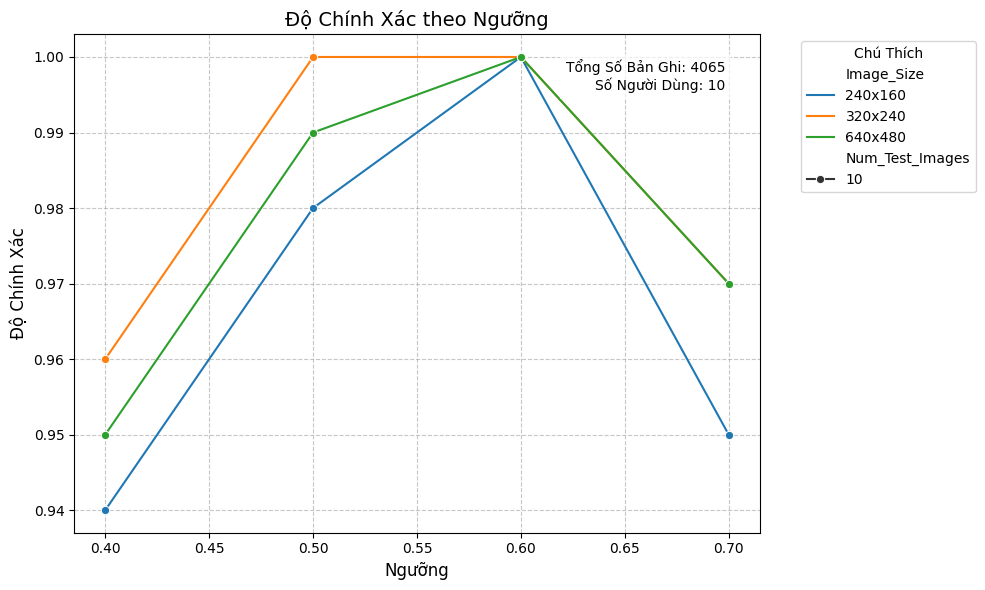

Biểu đồ Accuracy lưu tại ./results/accuracy_vs_tolerance.png


In [41]:
# Block 3: Vẽ biểu đồ Accuracy
try:
    results_df
except NameError:
    results_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'comparison_results.csv'))

try:
    metrics
except NameError:
    metrics = pd.read_csv(os.path.join(OUTPUT_DIR, 'metrics.csv'))

if results_df.empty or metrics.empty:
    print('Không có dữ liệu để vẽ biểu đồ.')
    exit(1)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=metrics,
    x='Tolerance',
    y='Accuracy',
    hue='Image_Size',
    style='Num_Test_Images',
    markers=True
)
plt.title('Độ Chính Xác theo Ngưỡng', fontsize=14)
plt.xlabel('Ngưỡng', fontsize=12)
plt.ylabel('Độ Chính Xác', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Chú Thích', fontsize=10)
plt.text(
    0.95, 0.95,
    f'Tổng Số Bản Ghi: {len(results_df)}\nSố Người Dùng: {metrics["Num_Users"].iloc[0]}',
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_vs_tolerance.png'), dpi=300)
plt.show()
print(f'Biểu đồ Accuracy lưu tại {os.path.join(OUTPUT_DIR, "accuracy_vs_tolerance.png")}')


<Figure size 1200x800 with 0 Axes>

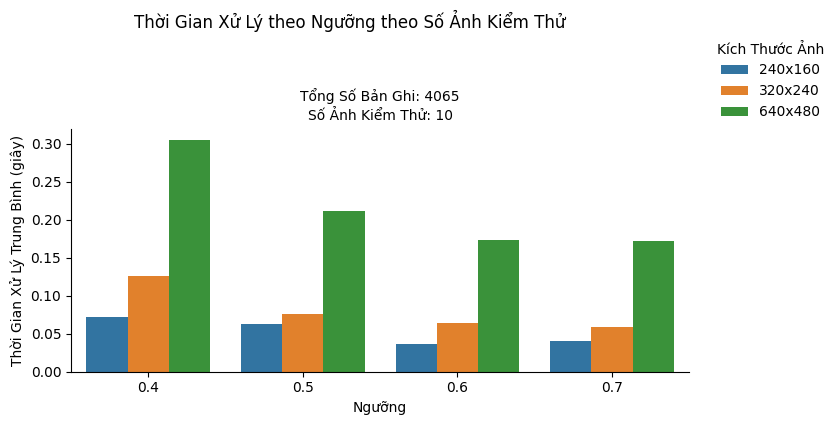

Biểu đồ Mean Time lưu tại ./results/time_vs_tolerance.png


In [40]:
# Block 4: Vẽ biểu đồ Mean Time
try:
    results_df
except NameError:
    results_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'comparison_results.csv'))

try:
    metrics
except NameError:
    metrics = pd.read_csv(os.path.join(OUTPUT_DIR, 'metrics.csv'))

if results_df.empty or metrics.empty:
    print('Không có dữ liệu để vẽ biểu đồ.')
    exit(1)

plt.figure(figsize=(12, 8))
g = sns.catplot(
    data=metrics,
    x='Tolerance',
    y='Mean_Time',
    hue='Image_Size',
    col='Num_Test_Images',
    kind='bar',
    height=4,
    aspect=1.2
)
g.set_axis_labels('Ngưỡng', 'Thời Gian Xử Lý Trung Bình (giây)')
g.set_titles('Số Ảnh Kiểm Thử: {col_name}')
g.fig.suptitle('Thời Gian Xử Lý theo Ngưỡng theo Số Ảnh Kiểm Thử', y=1.05)

if g._legend:
    g._legend.remove()

g.add_legend(bbox_to_anchor=(1, 1), loc='upper left', title='Kích Thước Ảnh')
g.legend.get_frame().set_linewidth(0)  

for ax in g.axes.flat:
    ax.text(
        0.5, 1.1, 
        f'Tổng Số Bản Ghi: {len(results_df)}',
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_vs_tolerance.png'), dpi=300)
plt.show()
print(f'Biểu đồ Mean Time lưu tại {os.path.join(OUTPUT_DIR, "time_vs_tolerance.png")}')